In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
df = pd.read_csv('../data/netflix_titles.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

First 3 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [3]:
print("=== Dataset Info ===")
df.info()
print("\n=== Statistical Summary ===")
df.describe(include='all')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

=== Statistical Summary ===


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


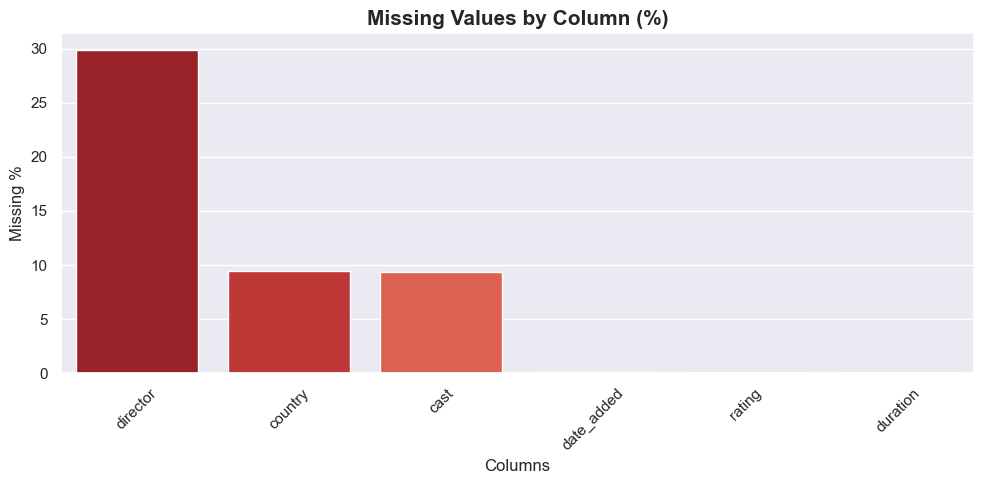

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

# Plot
plt.figure(figsize=(10, 5))
cols_with_nan = missing_df[missing_df['Missing Count'] > 0]
sns.barplot(x=cols_with_nan.index, y=cols_with_nan['Missing %'], palette='Reds_r')
plt.title('Missing Values by Column (%)', fontsize=15, fontweight='bold')
plt.xlabel('Columns')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150)
plt.show()

In [5]:
print("Shape BEFORE cleaning:", df.shape)

# ── Step 1: Fix the dirty 'rating' column
# '74 min', '84 min', '66 min' are durations wrongly placed in rating
# Move them to 'duration' and set those rating cells to NaN

duration_mask = df['rating'].isin(['74 min', '84 min', '66 min'])
print(f"\n⚠️ Found {duration_mask.sum()} rows with duration values in 'rating' column")
print(df[duration_mask][['title', 'rating', 'duration']])

# Move misplaced duration values → duration column
df.loc[duration_mask, 'duration'] = df.loc[duration_mask, 'rating']
# Clear those wrong rating values
df.loc[duration_mask, 'rating'] = np.nan

# ── Step 2: Fill NaN in categorical columns
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['duration'].fillna('Unknown', inplace=True)

# ── Step 3: Fill NaN rating with mode
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

# ── Step 4: Drop rows where date_added is NaN (only 10 rows — safe to drop)
df.dropna(subset=['date_added'], inplace=True)

# ── Step 5: Drop rows where core columns are NaN
df.dropna(subset=['title', 'type', 'listed_in'], inplace=True)

print("\nShape AFTER cleaning:", df.shape)

Shape BEFORE cleaning: (8807, 12)

⚠️ Found 3 rows with duration values in 'rating' column
                                     title  rating duration
5541                       Louis C.K. 2017  74 min      NaN
5794                 Louis C.K.: Hilarious  84 min      NaN
5813  Louis C.K.: Live at the Comedy Store  66 min      NaN

Shape AFTER cleaning: (8797, 12)


In [6]:
print("=" * 45)
print("     NaN CHECK AFTER CLEANING")
print("=" * 45)

remaining = df.isnull().sum()

if remaining.sum() == 0:
    print("✅ PERFECT! No NaN values remaining anywhere.")
else:
    print("⚠️ NaN still present:")
    print(remaining[remaining > 0])

     NaN CHECK AFTER CLEANING
✅ PERFECT! No NaN values remaining anywhere.


In [7]:
# Clean whitespace from all string columns
str_cols = ['title', 'director', 'cast', 'country',
            'rating', 'listed_in', 'description', 'duration']
for col in str_cols:
    df[col] = df[col].str.strip()

# Parse date_added
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name']  = df['date_added'].dt.strftime('%B')

# Extract numeric duration (works for both Movies and TV Shows)
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

print("✅ Feature engineering done!")
print(f"\nFinal dataset shape : {df.shape}")
print(f"Year range          : {int(df['year_added'].min())} → {int(df['year_added'].max())}")
print(f"Unique ratings      : {sorted(df['rating'].dropna().unique())}")
print(f"Content types       : {df['type'].unique()}")
df.head(3)

✅ Feature engineering done!

Final dataset shape : (8797, 16)
Year range          : 2008 → 2021
Unique ratings      : ['G', 'NC-17', 'NR', 'PG', 'PG-13', 'R', 'TV-14', 'TV-G', 'TV-MA', 'TV-PG', 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'UR']
Content types       : ['Movie' 'TV Show']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name,duration_int
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,September,90.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,September,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,September,1.0


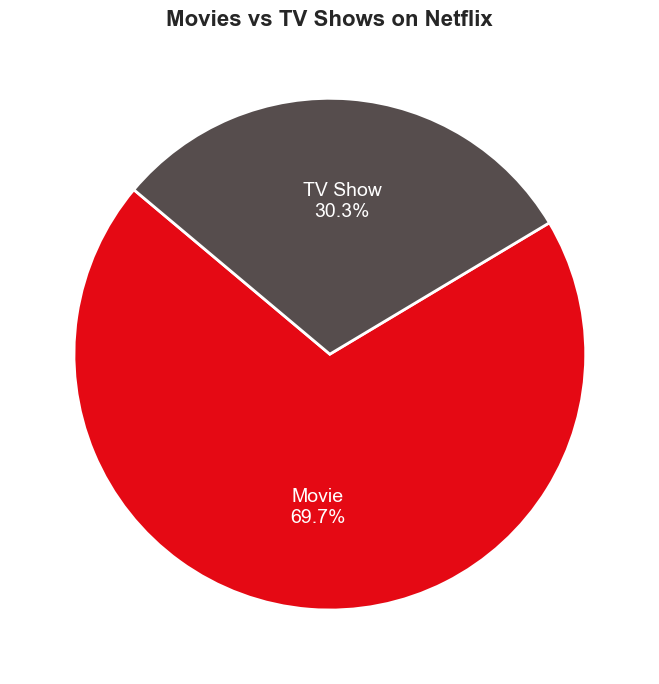

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


In [8]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(7, 7))

# Custom function to show label + percentage
def autopct_func(pct):
    total = sum(type_counts)
    count = int(round(pct * total / 100.0))
    label = type_counts.index[list(type_counts).index(count)] if count in type_counts.values else ''
    return f'{label}\n{pct:.1f}%'

plt.pie(type_counts,
        labels=None,   # remove outside labels
        autopct=lambda pct: f"{type_counts.index[list(type_counts).index(int(round(pct*sum(type_counts)/100.0)))]}\n{pct:.1f}%",
        colors=['#E50914', '#564d4d'],
        startangle=140,
        textprops={'fontsize': 14, 'color': 'white'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Movies vs TV Shows on Netflix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/movies_vs_tvshows.png', dpi=150)
plt.show()

print(type_counts)

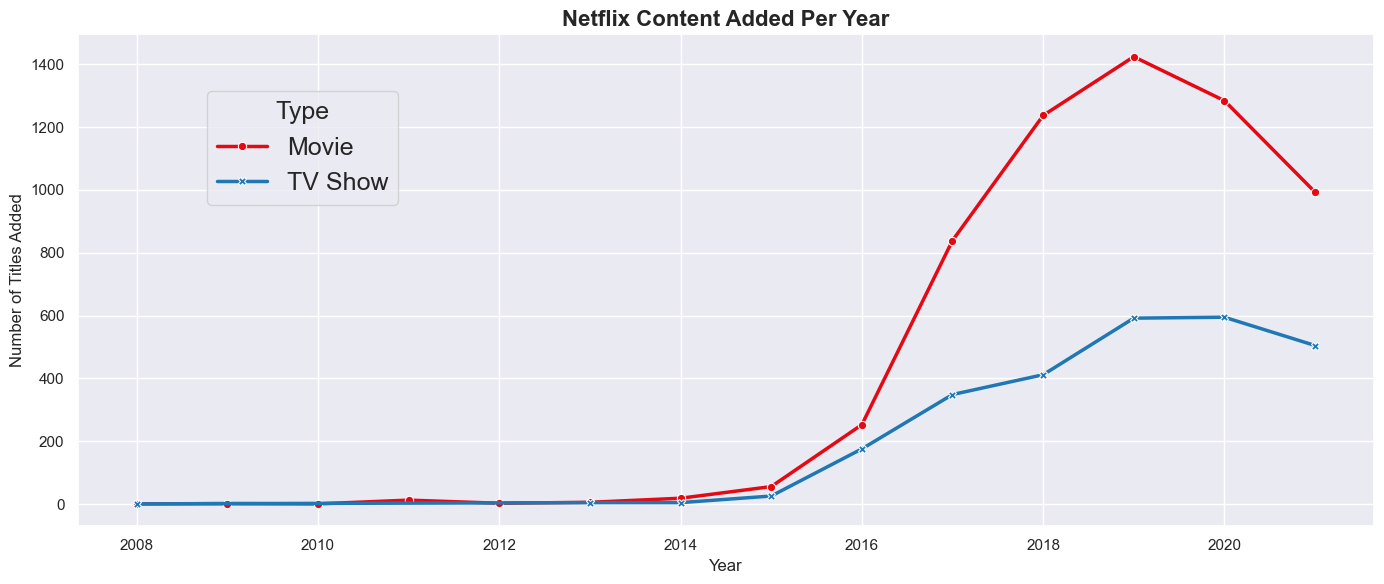

In [9]:
yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(14, 6))

# Explicit color mapping (fixes same color issue)
palette = {
    'Movie': '#E50914',   # Netflix red
    'TV Show': '#1f77b4'  # blue for contrast
}

sns.lineplot(data=yearly,
             x='year_added',
             y='count',
             hue='type',
             style='type',        # different styles for clarity
             markers=True,
             dashes=False,
             linewidth=2.5,
             palette=palette)

plt.title('Netflix Content Added Per Year', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.legend(title='Type',
           loc='upper left',
           bbox_to_anchor=(0.09, 0.91),
           fontsize=18,
           title_fontsize=18,
           frameon=True)
plt.tight_layout()
plt.savefig('../images/content_over_years.png', dpi=150)
plt.show()

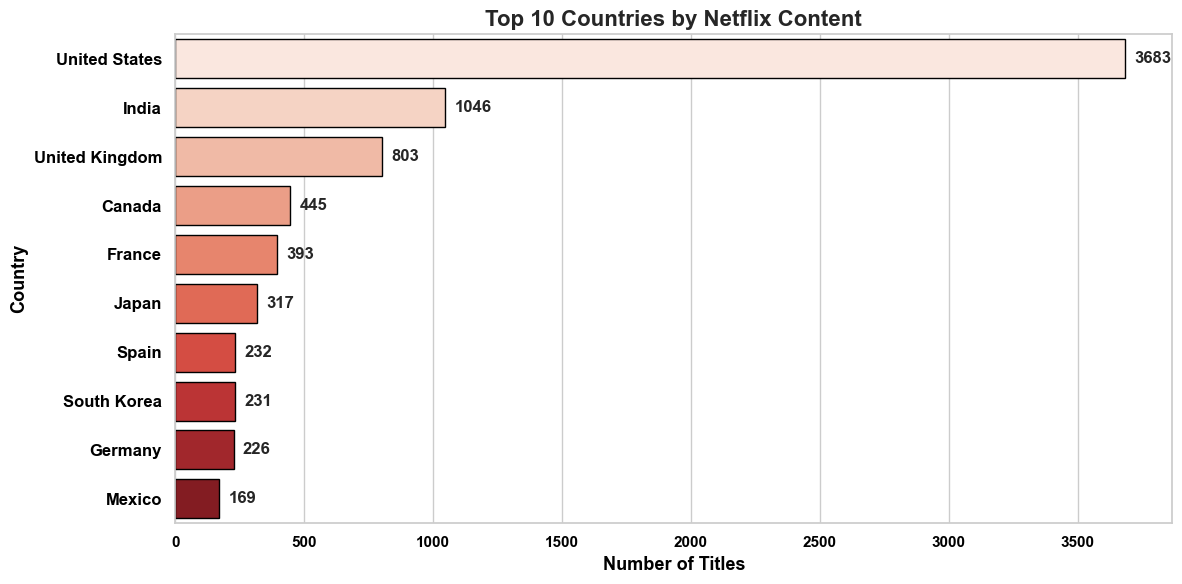

In [10]:
country_series = df['country'].str.split(', ').explode()
top_countries = country_series[country_series != 'Unknown'].value_counts().head(10)

# ✅ Sort so highest appears at TOP
top_countries = top_countries.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

palette = sns.color_palette("Reds", len(top_countries))

sns.barplot(x=top_countries.values,
            y=top_countries.index,
            palette=palette,
            edgecolor='black')

plt.title('Top 10 Countries by Netflix Content', fontsize=16, fontweight='bold')

# ✅ Bold axis labels
plt.xlabel('Number of Titles', fontsize=13, fontweight='bold', color='black')
plt.ylabel('Country', fontsize=13, fontweight='bold', color='black')

# ✅ Bold ticks
plt.yticks(fontsize=12, fontweight='bold', color='black')
plt.xticks(fontsize=11, fontweight='bold', color='black')

# ✅ Add values on bars
for i, v in enumerate(top_countries.values):
    plt.text(v + max(top_countries.values)*0.01, i, str(v),
             va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/top_countries.png', dpi=150)
plt.show()

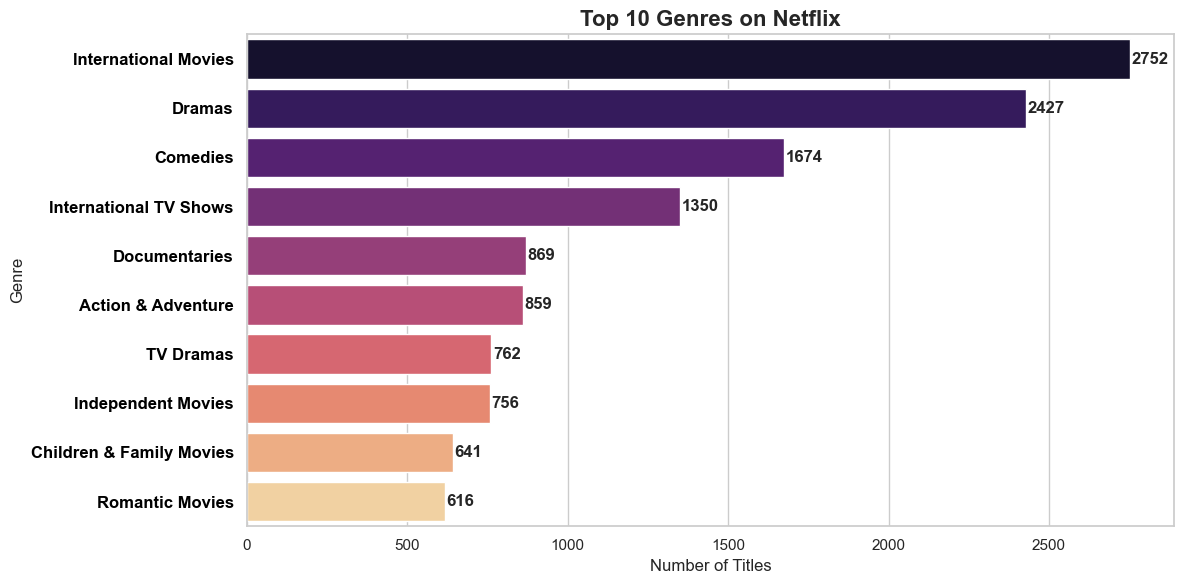

In [11]:
genre_series = df['listed_in'].str.split(', ').explode()
top_genres = genre_series.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')
plt.title('Top 10 Genres on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.yticks(fontsize=12, fontweight='bold', color='black')
plt.xticks(fontsize=11)

for i, v in enumerate(top_genres.values):
    plt.text(v + 5, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/top_genres.png', dpi=150)
plt.show()

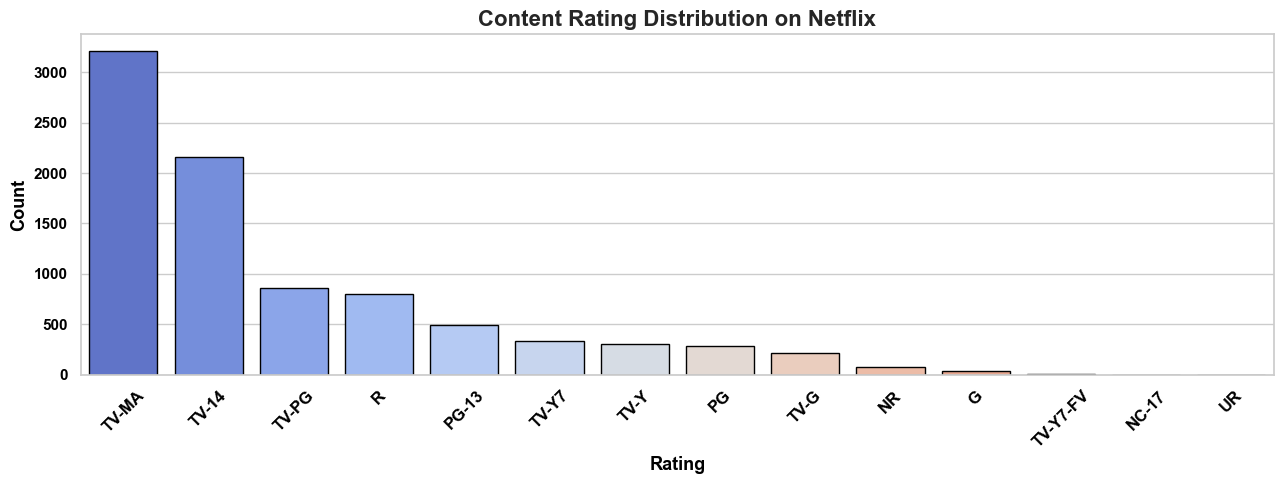

In [12]:
# Only keep actual rating values (filter out any remaining garbage)
valid_ratings = ['G', 'PG', 'PG-13', 'R', 'NC-17', 'NR', 'UR',
                 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'TV-G',
                 'TV-PG', 'TV-14', 'TV-MA']

df_ratings = df[df['rating'].isin(valid_ratings)]
rating_order = df_ratings['rating'].value_counts().index.tolist()

plt.figure(figsize=(13, 5))
sns.set_style("whitegrid")

sns.countplot(data=df_ratings,
              x='rating',
              order=rating_order,
              palette='coolwarm',
              edgecolor='black')

plt.title('Content Rating Distribution on Netflix', fontsize=16, fontweight='bold')

#  Make axis labels bold + bigger
plt.xlabel('Rating', fontsize=13, fontweight='bold', color='black')
plt.ylabel('Count', fontsize=13, fontweight='bold', color='black')

# Tick styling
plt.xticks(rotation=45, fontsize=12, fontweight='bold', color='black')
plt.yticks(fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('../images/ratings_distribution.png', dpi=150)
plt.show()

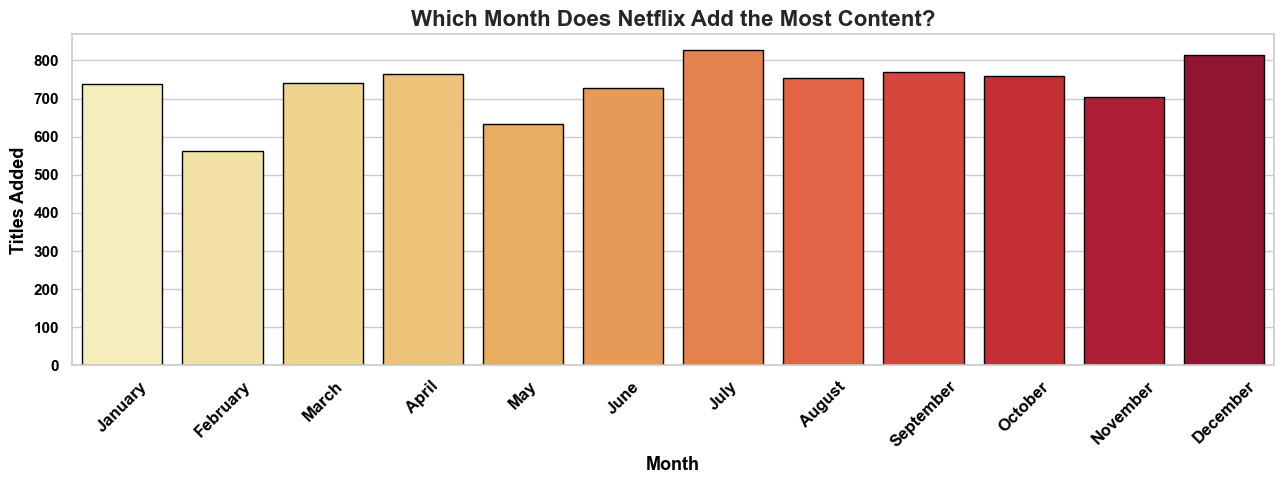

In [13]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly = df.groupby('month_name').size().reindex(month_order)

plt.figure(figsize=(13, 5))
sns.set_style("whitegrid")

sns.barplot(x=monthly.index,
            y=monthly.values,
            palette='YlOrRd',
            edgecolor='black')

plt.title('Which Month Does Netflix Add the Most Content?', fontsize=16, fontweight='bold')

# ✅ Bold axis labels
plt.xlabel('Month', fontsize=13, fontweight='bold', color='black')
plt.ylabel('Titles Added', fontsize=13, fontweight='bold', color='black')

# ✅ Bold ticks
plt.xticks(rotation=45, fontsize=12, fontweight='bold', color='black')
plt.yticks(fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('../images/best_month.png', dpi=150)
plt.show()

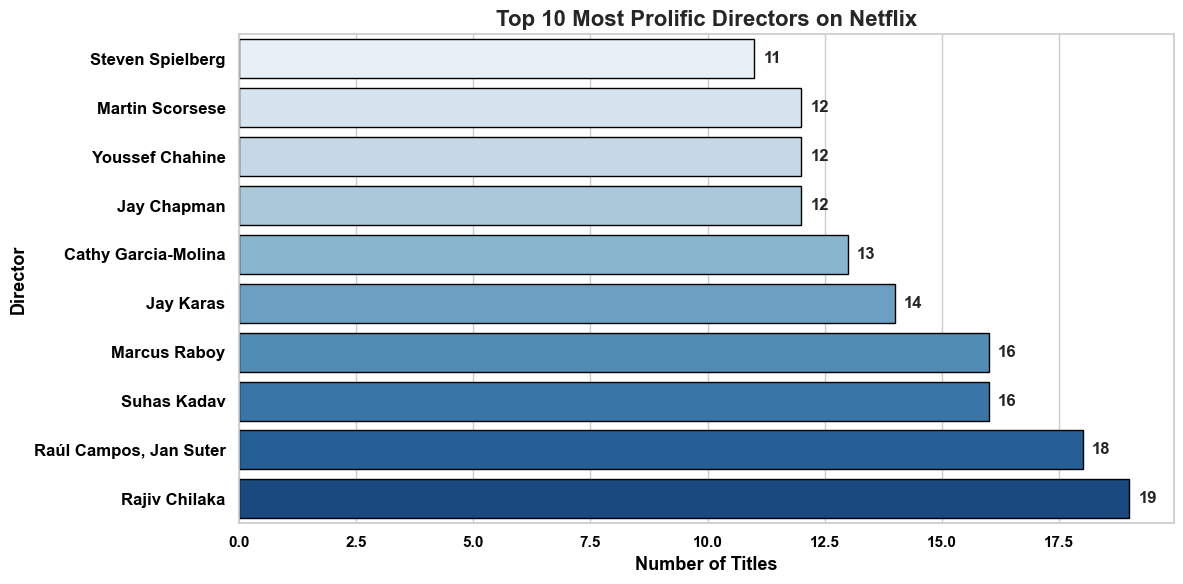

In [14]:
directors = df[df['director'] != 'Unknown']['director']
top_directors = directors.value_counts().head(10)

# Sort for better horizontal visualization
top_directors = top_directors.sort_values()

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

palette = sns.color_palette("Blues", len(top_directors))

sns.barplot(x=top_directors.values,
            y=top_directors.index,
            palette=palette,
            edgecolor='black')

plt.title('Top 10 Most Prolific Directors on Netflix', fontsize=16, fontweight='bold')

# ✅ Bold axis labels
plt.xlabel('Number of Titles', fontsize=13, fontweight='bold', color='black')
plt.ylabel('Director', fontsize=13, fontweight='bold', color='black')

# ✅ Bold ticks
plt.xticks(fontsize=11, fontweight='bold', color='black')
plt.yticks(fontsize=12, fontweight='bold', color='black')

# Optional: add values on bars
for i, v in enumerate(top_directors.values):
    plt.text(v + max(top_directors.values)*0.01, i, str(v),
             va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/top_directors.png', dpi=150)
plt.show()

## 🔍 Key Insights from Netflix EDA

1. **Movies dominate** — roughly 70% of all content is Movies vs 30% TV Shows.
2. **Rapid growth** — Netflix added content aggressively between 2016–2019.
3. **USA, India, UK** are the top 3 content-producing countries.
4. **International Movies and Dramas** are the most common genres.
5. **TV-MA and TV-14** dominate ratings — Netflix leans toward mature content.
6. **January and July** see the highest content additions.
7. **3 rows had corrupted data** — duration values were wrongly placed in the rating column. These were detected and fixed during cleaning.
8. **Director data is sparse** — nearly 30% of titles have no director listed (common for stand-up specials and documentaries).